# 04 — `filt`: bandpass / bandstop / gaussian

`dsp.filt.bandpass(x, fs, bands)` accepts a list of `[(lo, hi), ...]`
ranges and returns one filtered signal per band, stacked on a new
axis.

filtered: (1, 1, 3, 1024)


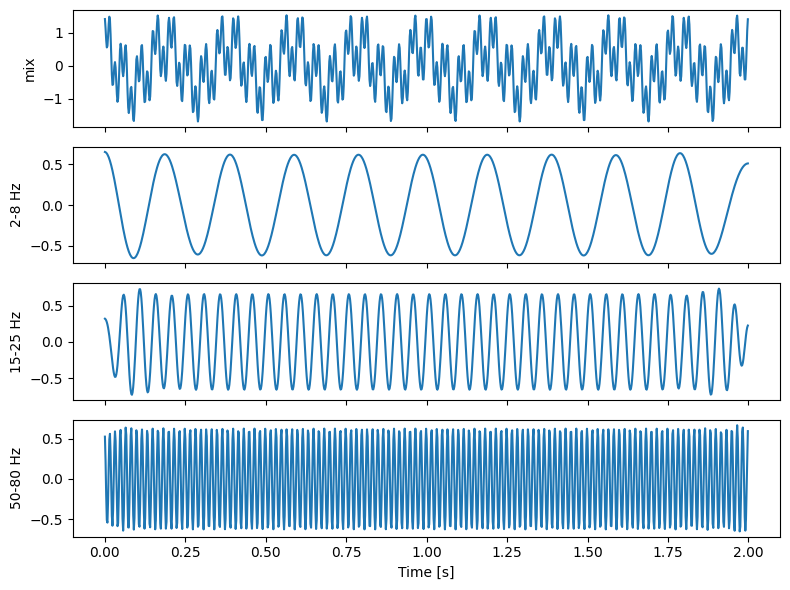

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import scitex_dsp as dsp
%matplotlib inline

xx, tt, fs = dsp.demo_sig(sig_type="periodic", batch_size=1, n_chs=1,
                          t_sec=2, fs=512, freqs_hz=[5, 20, 60])
bands = [(2, 8), (15, 25), (50, 80)]
yy = np.asarray(dsp.filt.bandpass(xx, fs=fs, bands=bands))
print("filtered:", yy.shape)

fig, ax = plt.subplots(len(bands)+1, 1, figsize=(8, 6), sharex=True)
ax[0].plot(tt, xx[0, 0]); ax[0].set_ylabel("mix")
for i, (lo, hi) in enumerate(bands):
    ax[i+1].plot(tt, yy[0, 0, i])
    ax[i+1].set_ylabel(f"{lo}-{hi} Hz")
ax[-1].set_xlabel("Time [s]"); fig.tight_layout()
plt.show()


`dsp.filt.bandstop(x, fs, bands)` — same shape contract, inverted role (notch out 50/60 Hz mains, etc.).